# Dynamic Dataset Inspection

This notebook loads a parquet dataset and inspects:
- entry_representation
- toxicity_representation
- lob_sequence

The goal is to quickly confirm whether the stored tensor/list structure matches your expected dynamic DeepHit inputs.

In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
DATASET_PATH = PROJECT_ROOT / "data" / "datasets" / "dataset_XNAS_ITCH_AAPL_mbo_20260105_20260110.parquet"

print(f"Dataset path: {DATASET_PATH}")
print(f"Exists: {DATASET_PATH.exists()}")

Dataset path: C:\Users\AngusCheung\OneDrive\PycharmProjects\lob-deep-survival-analysis\data\datasets\dataset_XNAS_ITCH_AAPL_mbo_20260105_20260110.parquet
Exists: True


In [ ]:
df = pd.read_parquet(DATASET_PATH).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Cols: {len(df.columns)}")
print("\nColumns:")
print(df.columns.tolist())

display(df.head(3))

Rows: 1,000
Cols: 23

Columns:
['order_id', 'entry_time', 'duration_s', 'event', 'status_reason', 'price', 'side', 'volume', 'order_type', 'best_bid_at_entry', 'best_ask_at_entry', 'best_bid_at_post_trade', 'best_ask_at_post_trade', 'entry_representation', 'toxicity_representation', 'lob_sequence', 'toxicity_sequence', 'sequence_length', 'event_type', 'event_time_bin', 'post_trade_adverse_move_bps', 'post_trade_spread_bps', 'post_trade_recorded']


,order_id,entry_time,duration_s,event,status_reason,price,side,volume,order_type,best_bid_at_entry,...,entry_representation,toxicity_representation,lob_sequence,toxicity_sequence,sequence_length,event_type,event_time_bin,post_trade_adverse_move_bps,post_trade_spread_bps,post_trade_recorded
0,1,1767623401129998336,0.394239,1,FILLED,270990000000,A,1,VIRTUAL,270890000000,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[430000000.0, 15.88386344909668, -0.238095238...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[430000000.0, 15.88386344909668, -0.238095238...",14,1,7,-0.553628,4.060164,True
1,0,1767623401129998336,0.444960,1,FILLED,270890000000,B,1,VIRTUAL,270890000000,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[430000000.0, 15.88386344909668, -0.238095238...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[430000000.0, 15.88386344909668, -0.238095238...",14,2,7,1.476342,5.906238,True
2,2,1767623483608507904,0.185625,1,FILLED,270310000000,B,1,VIRTUAL,270310000000,...,"[[-3016.0, -3016.0, -3008.0, -3008.0, -3000.0,...","[[160000000.0, 5.916284561157227, -0.952380955...","[[-3016.0, -3016.0, -3008.0, -3008.0, -3000.0,...","[[160000000.0, 5.916284561157227, -0.952380955...",21,1,5,0.184956,2.959346,True


In [11]:
def nested_shape(x):
    """Infer nested list shape (best effort)."""
    if x is None:
        return ()
    if hasattr(x, "shape"):
        try:
            return tuple(x.shape)
        except Exception:
            pass
    if isinstance(x, (list, tuple)):
        if len(x) == 0:
            return (0,)
        return (len(x),) + nested_shape(x[0])
    return ()

def first_valid_value(series):
    for v in series:
        if v is None:
            continue
        if isinstance(v, float) and np.isnan(v):
            continue
        return v
    return None

def safe_len(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return len(x)
    return np.nan

def to_2d_array(x):
    """Convert nested list/array-like payloads into a numeric 2D array if possible."""
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        if x.ndim == 2:
            try:
                return x.astype(float)
            except Exception:
                pass
        if x.ndim == 1 and len(x) > 0 and isinstance(x[0], (list, tuple, np.ndarray)):
            rows = []
            for step in x:
                arr1 = np.asarray(step).reshape(-1)
                try:
                    arr1 = arr1.astype(float)
                except Exception:
                    return None
                rows.append(arr1)
            widths = {r.shape[0] for r in rows}
            if len(widths) == 1 and len(rows) > 0:
                return np.vstack(rows)
            return None
        return None
    if isinstance(x, (list, tuple)):
        if len(x) == 0:
            return np.zeros((0, 0), dtype=float)
        rows = []
        for step in x:
            arr1 = np.asarray(step).reshape(-1)
            try:
                arr1 = arr1.astype(float)
            except Exception:
                return None
            rows.append(arr1)
        widths = {r.shape[0] for r in rows}
        if len(widths) == 1 and len(rows) > 0:
            return np.vstack(rows)
        return None
    return None

In [6]:
target_cols = ["entry_representation", "toxicity_representation", "lob_sequence", "toxicity_sequence", "sequence_length"]
present_cols = [c for c in target_cols if c in df.columns]
missing_cols = [c for c in target_cols if c not in df.columns]

print("Present target columns:", present_cols)
print("Missing target columns:", missing_cols)

for col in present_cols:
    nulls = int(df[col].isna().sum()) if hasattr(df[col], "isna") else 0
    sample = first_valid_value(df[col])
    print(f"\n[{col}]")
    print(f"  null count: {nulls:,}")
    print(f"  sample nested shape: {nested_shape(sample)}")
    if isinstance(sample, (list, tuple)) and len(sample) > 0:
        first_step = sample[0]
        if isinstance(first_step, (list, tuple)):
            print(f"  first step length: {len(first_step)}")
        else:
            print(f"  first value type: {type(first_step)}")

Present target columns: ['entry_representation', 'toxicity_representation', 'lob_sequence', 'toxicity_sequence', 'sequence_length']
Missing target columns: []

[entry_representation]
  null count: 0
  sample nested shape: (11,)

[toxicity_representation]
  null count: 0
  sample nested shape: (11,)

[lob_sequence]
  null count: 0
  sample nested shape: (14,)

[toxicity_sequence]
  null count: 0
  sample nested shape: (14,)

[sequence_length]
  null count: 0
  sample nested shape: ()


In [12]:
if "entry_representation" in df.columns:
    entry_len = df["entry_representation"].map(safe_len)
    print("entry_representation length stats:")
    print(entry_len.describe())

if "lob_sequence" in df.columns:
    lob_len = df["lob_sequence"].map(safe_len)
    print("\nlob_sequence length stats:")
    print(lob_len.describe())

if "toxicity_sequence" in df.columns:
    tox_len = df["toxicity_sequence"].map(safe_len)
    print("\ntoxicity_sequence length stats:")
    print(tox_len.describe())

entry_representation length stats:
count    1000.000000
mean       19.982000
std         0.402291
min        11.000000
25%        20.000000
50%        20.000000
75%        20.000000
max        20.000000
Name: entry_representation, dtype: float64

lob_sequence length stats:
count    1000.000000
mean       66.241000
std       151.133187
min        14.000000
25%        22.000000
50%        27.000000
75%        47.000000
max      1892.000000
Name: lob_sequence, dtype: float64

toxicity_sequence length stats:
count    1000.000000
mean       66.241000
std       151.133187
min        14.000000
25%        22.000000
50%        27.000000
75%        47.000000
max      1892.000000
Name: toxicity_sequence, dtype: float64


Using row position: 400


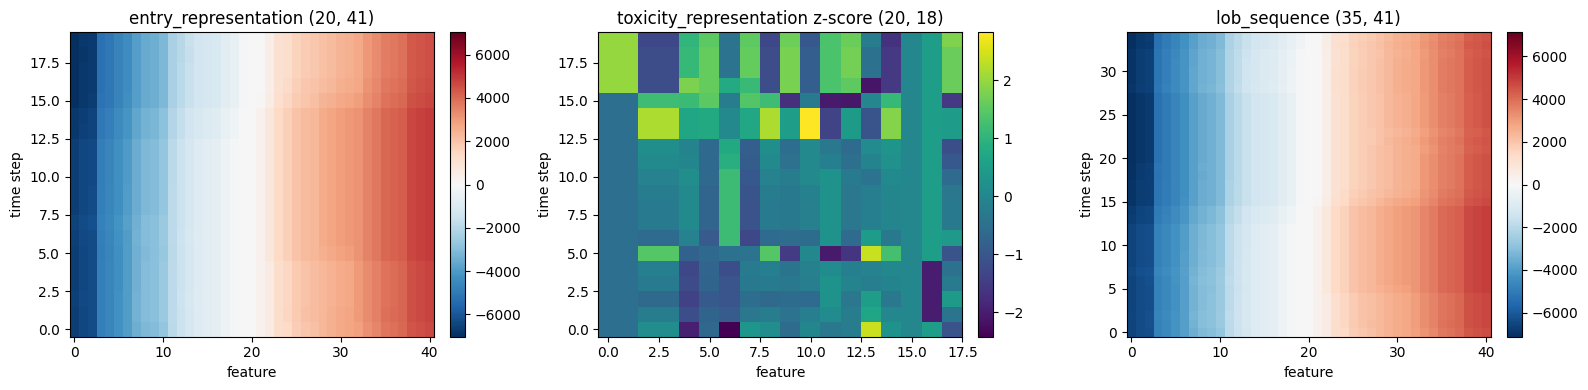

In [23]:
row_pos = 400
while row_pos < len(df):
    ok = True
    if "entry_representation" in df.columns:
        ok = ok and safe_len(df.iloc[row_pos]["entry_representation"]) > 0
    if "lob_sequence" in df.columns:
        ok = ok and safe_len(df.iloc[row_pos]["lob_sequence"]) > 0
    if ok:
        break
    row_pos += 1

if row_pos >= len(df):
    row_pos = 0

print(f"Using row position: {row_pos}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if "entry_representation" in df.columns:
    arr = to_2d_array(df.iloc[row_pos]["entry_representation"])
    if arr is not None and arr.ndim == 2 and arr.size > 0:
        vmax_entry = float(np.nanmax(np.abs(arr)))
        if not np.isfinite(vmax_entry) or vmax_entry == 0.0:
            vmax_entry = 1.0
        im0 = axes[0].imshow(
            arr,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
            cmap="RdBu_r",
            vmin=-vmax_entry,
            vmax=vmax_entry,
        )
        axes[0].set_title(f"entry_representation {arr.shape}")
        axes[0].set_xlabel("feature")
        axes[0].set_ylabel("time step")
        fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    else:
        axes[0].text(0.5, 0.5, "not 2D", ha="center", va="center")
        axes[0].set_title("entry_representation")

if "toxicity_representation" in df.columns:
    arr = to_2d_array(df.iloc[row_pos]["toxicity_representation"])
    if arr is not None and arr.ndim == 2 and arr.size > 0:
        # Standardize each feature column over time for this sample.
        feat_mean = np.nanmean(arr, axis=0, keepdims=True)
        feat_std = np.nanstd(arr, axis=0, keepdims=True)
        feat_std = np.where((~np.isfinite(feat_std)) | (feat_std == 0.0), 1.0, feat_std)
        arr_std = (arr - feat_mean) / feat_std
        arr_std = np.nan_to_num(arr_std, nan=0.0, posinf=0.0, neginf=0.0)

        im1 = axes[1].imshow(
            arr_std,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
        )
        axes[1].set_title(f"toxicity_representation z-score {arr.shape}")
        axes[1].set_xlabel("feature")
        axes[1].set_ylabel("time step")
        fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    else:
        axes[1].text(0.5, 0.5, "not 2D", ha="center", va="center")
        axes[1].set_title("toxicity_representation")

if "lob_sequence" in df.columns:
    arr = to_2d_array(df.iloc[row_pos]["lob_sequence"])
    if arr is not None and arr.ndim == 2 and arr.size > 0:
        vmax_lob = float(np.nanmax(np.abs(arr)))
        if not np.isfinite(vmax_lob) or vmax_lob == 0.0:
            vmax_lob = 1.0
        im2 = axes[2].imshow(
            arr,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
            cmap="RdBu_r",
            vmin=-vmax_lob,
            vmax=vmax_lob,
        )
        axes[2].set_title(f"lob_sequence {arr.shape}")
        axes[2].set_xlabel("feature")
        axes[2].set_ylabel("time step")
        fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    else:
        axes[2].text(0.5, 0.5, "not 2D", ha="center", va="center")
        axes[2].set_title("lob_sequence")

plt.tight_layout()
plt.show()

In [20]:
inspect_cols = [c for c in ["order_id", "status_reason", "duration_s", "event_type", "event_time_bin", "sequence_length"] if c in df.columns]
display(df.iloc[[row_pos]][inspect_cols])

if "entry_representation" in df.columns and "lob_sequence" in df.columns:
    entry_len = safe_len(df.iloc[row_pos]["entry_representation"])
    lob_len = safe_len(df.iloc[row_pos]["lob_sequence"])
    print(f"entry_representation length: {entry_len}")
    print(f"lob_sequence length: {lob_len}")
    print("If lob_sequence > entry_representation, that reflects post-entry dynamic updates during wait time.")

,order_id,status_reason,duration_s,event_type,event_time_bin,sequence_length
400,403,FILLED,2.96873,2,11,35


entry_representation length: 20
lob_sequence length: 35
If lob_sequence > entry_representation, that reflects post-entry dynamic updates during wait time.
